In [4]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [5]:
train_path=r"C:\Users\kumar\Downloads\archive (14)\seg_train\seg_train"

In [6]:
import keras

In [7]:
x=tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224,224),
    batch_size=32
)

Found 14034 files belonging to 6 classes.


In [8]:
test_path=r"C:\Users\kumar\Downloads\archive (14)\seg_test\seg_test"
y=tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32)

Found 3000 files belonging to 6 classes.


In [9]:
class_name=x.class_names

In [10]:
print(y.class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


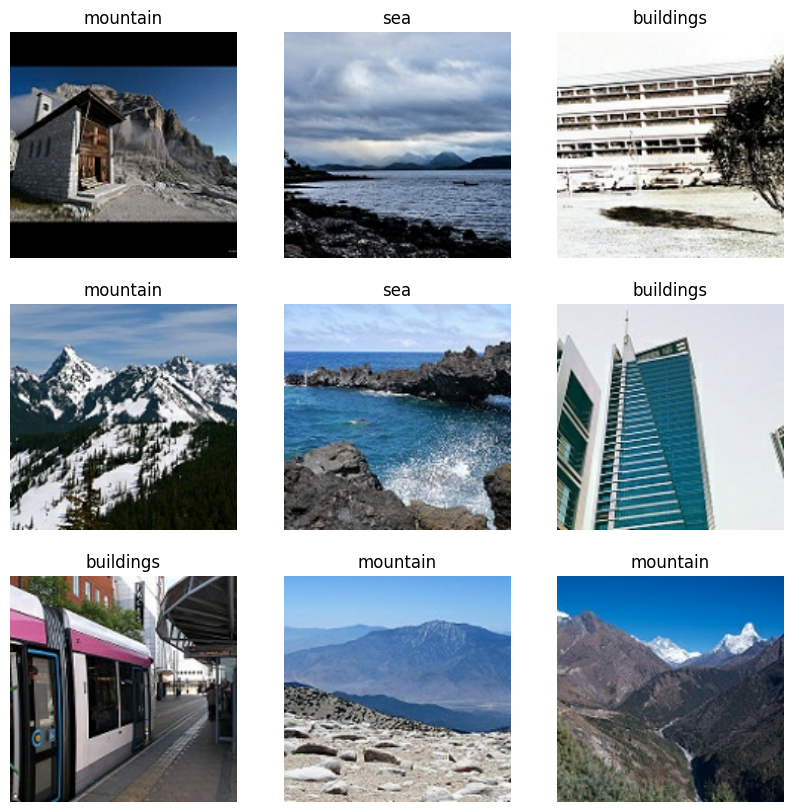

In [11]:
for images,labels in x.take(1):
    plt.figure(figsize=(10,10))

for i in range (9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_name[labels[i]])
    plt.axis("off")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split


In [ ]:
model=keras.Sequential([
    
    keras.layers.Conv2D(filters=100,input_shape=(224,224,3),kernel_size=(2,2),activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(filters=50,kernel_size=(2,2),activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(filters=10,kernel_size=(2,2),activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(500,activation="relu"),
    keras.layers.Dense(300,activation="relu"),
    keras.layers.Dense(100,activation="relu"),
    keras.layers.Dense(len(class_name),activation="sigmoid")

])
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=['accuracy'])
model.fit(x,epochs=5)

Epoch 1/5


c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


404/439 ━━━━━━━━━━━━━━━━━━━━ 34s 994ms/step - accuracy: 0.3670 - loss: 1.7345

In [ ]:
model.evaluate(y)

94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - accuracy: 0.5437 - loss: 1.7210


[1.7210158109664917, 0.543666660785675]

In [ ]:
r=r"C:\Users\kumar\Downloads\archive (14)\seg_pred\seg_pred"

In [ ]:
# pre=tf.keras.utils.image_dataset_from_directory(
#     r,
#     image_size=(224,224)
# )

In [ ]:
pre=model.predict(y)


94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step


In [ ]:
predict=[]
for i in range(len(pre)):
    predict.append(np.argmax(pre[i]))

In [ ]:
print("Actual:",class_name[actual_classes[55]]," Predict:",class_name[(predict[55])])

Actual: street  Predict: mountain


In [ ]:
np.argmax(pre[0])

np.int64(5)

In [ ]:
x.class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [ ]:
y.class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [ ]:
pre_class=np.argmax(pre,axis=1)

In [ ]:
actual_classes[0]

np.int32(1)

In [ ]:
actual_classes = np.concatenate([labels for images, labels in y])

for i in range(len(y)):
    print(
        "Actual:", class_name[actual_classes[i]],
        "| Predicted:", class_name[pre_class[i]]
    )

Actual: forest | Predicted: street
Actual: glacier | Predicted: glacier
Actual: street | Predicted: street
Actual: glacier | Predicted: street
Actual: sea | Predicted: forest
Actual: mountain | Predicted: forest
Actual: buildings | Predicted: glacier
Actual: glacier | Predicted: glacier
Actual: glacier | Predicted: mountain
Actual: mountain | Predicted: glacier
Actual: glacier | Predicted: mountain
Actual: glacier | Predicted: forest
Actual: street | Predicted: street
Actual: forest | Predicted: forest
Actual: street | Predicted: glacier
Actual: street | Predicted: sea
Actual: buildings | Predicted: buildings
Actual: sea | Predicted: sea
Actual: glacier | Predicted: forest
Actual: street | Predicted: glacier
Actual: glacier | Predicted: glacier
Actual: glacier | Predicted: glacier
Actual: glacier | Predicted: glacier
Actual: mountain | Predicted: street
Actual: street | Predicted: buildings
Actual: forest | Predicted: glacier
Actual: forest | Predicted: street
Actual: street | Predicte

In [ ]:
actual_classes

array([0, 0, 4, ..., 3, 0, 1], shape=(3000,), dtype=int32)